In [1]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.stats import gamma as gamma_dist

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC

numpyro.set_host_device_count(1)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'✓ Device (PyTorch): {device}')
print(f'✓ JAX backend: {jax.default_backend()}')
print(f'✓ numpyro {numpyro.__version__}, jax {jax.__version__}')

_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f'✓ Working directory: {os.getcwd()}')

from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print('✓ PFNs načteny')

✓ Device (PyTorch): mps
✓ JAX backend: cpu
✓ numpyro 0.16.1, jax 0.4.35
✓ Working directory: /Users/ruslanguliev/VU_RG
✓ PFNs načteny


In [2]:
# =============================================
# NAČTENÍ MODELŮ — pomocná funkce
# =============================================
# DŮLEŽITÉ: get_batch_for_gp_random_hps musí být definována PŘED torch.load

def get_batch_for_gp_random_hps(batch_size, seq_len, num_features,
                                  device='cpu', hyperparameters=None, **kwargs):
    hps = {'lengthscale': 0.3, 'outputscale': 0.1, 'noise': 1.0}
    return get_batch_for_gp(batch_size, seq_len, num_features,
                             device=device, hyperparameters=hps, **kwargs)


def load_for_inference(checkpoint_path, device='cpu'):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config = checkpoint['config']

    if 'num_features' in config:
        num_features     = config['num_features']
        max_dataset_size = config['max_dataset_size']
        criterion        = checkpoint['criterion']
        borders          = criterion.borders.tolist()
        nlayers          = config.get('nlayers', 6)
        hps = config.get('hps', {})
        if hps:
            get_batch_fn = get_batch_for_gp
            prior_kwargs = {'num_features': num_features, 'hyperparameters': hps}
        else:
            get_batch_fn = get_batch_for_gp_random_hps
            prior_kwargs = {'num_features': num_features, 'hyperparameters': {}}
    else:
        num_features     = config['priors'][0]['prior_kwargs']['num_features']
        max_dataset_size = config['batch_shape_sampler']['max_seq_len']
        borders          = config['model']['criterion']['borders']
        nlayers          = config['model'].get('nlayers', 6)
        get_batch_fn     = get_batch_for_gp_random_hps
        prior_kwargs     = {'num_features': num_features, 'hyperparameters': {}}
        criterion        = None

    model_config = MainConfig(
        priors=[AdhocPriorConfig(
            get_batch_methods=[get_batch_fn],
            prior_kwargs=prior_kwargs
        )],
        optimizer=OptimizerConfig('adamw', lr=0.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            emsize=512, nhead=8, nhid=1024, nlayers=nlayers,
            features_per_group=1, attention_between_features=False,
            encoder=EncoderConfig(
                constant_normalization_mean=0.5,
                constant_normalization_std=math.sqrt(1/12)
            )
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(
            batch_size=2, max_seq_len=max_dataset_size,
            min_num_features=num_features, max_num_features=num_features
        ),
        epochs=1, steps_per_epoch=1, num_workers=0,
    )

    dummy_result = train(model_config, device=device, reusable_config=False)
    model = dummy_result['model']
    model.load_state_dict(checkpoint['model_state_dict'])
    if criterion is not None:
        model.criterion = criterion
    model.to(device)
    model.eval()

    epoch = checkpoint.get('epoch', '?')
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  ✓ {os.path.basename(checkpoint_path)}: nlayers={nlayers}, epoch={epoch}, {n_params:.1f}M params')
    return model, epoch

In [3]:
# =============================================
# NAČTENÍ MODELU (6-layer, random HP distribuce)
# =============================================

MODEL_PATH = os.path.join('models', 'pfn_rand_hps_6layer.pth')
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = os.path.join('models', 'pfn_rand_hps_6L_1000epoch.pth')

print(f'Načítám model: {MODEL_PATH}')
model_pfn, _ = load_for_inference(MODEL_PATH, device)
print('✓ Model připraven')

Načítám model: models/pfn_rand_hps_6layer.pth
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size, seq_len, num_features, device='mps', hyperparameters=None, equidistant_x=False, fix_x=None, **kwargs)
), num_features=1, hyperparameters={'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=120, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<pfns.priors.fast_gp.get_batch (batch_size, seq_len, num_features,

## Experiment 7: Robustnost při misspecifikaci prioru — PFN vs. GP

### Motivace

V předchozích experimentech jsme vždy věděli správné hyperparametry (délku korelace $\ell$, šum $\sigma^2$). V praxi to tak nikdy není. Otázka proto zní:

> **Když nikdo nezná správný prior, kdo selže míň — PFN, nebo klasický GP?**

---

### Jak data vznikají

Data generujeme z **Matérn 2.5** kernelu s $\ell = 0.3$ a šumem $\sigma^2 = 0.1$.
To je "pravda" — nikdo z níže popsaných metod o ní neví.

---

### Porovnávané metody

**PFN (6-layer)**
Natrénovaný transformer, jehož implicitní prior pochází z trénovací distribuce:
RBF kernel s $\ell \sim U(0.05, 1.0)$. Misspecifikace je dvojí: špatná rodina kernelů (RBF místo Matérn) a prior na $\ell$, který nelze za běhu inference opravit.

**GP_fixed**
Gaussovský proces s RBF kernelem a napevno nastaveným $\ell = 0.7$. Nejjednodušší baseline — špatné jádro i špatná hodnota $\ell$, nic se nepřizpůsobuje.

**GP_ML** (Type-II maximum likelihood)
Gaussovský proces s RBF kernelem, kde $\ell$ určuje maximalizace marginální věrohodnosti:
$$\hat{\ell} = \arg\max_{\ell}\; p(y \mid X, \ell)$$
Jde o bodový odhad — ekvivalent MLE pro hyperparametry (proto "Type-II ML" nebo "empirical Bayes"). Kernel je pořád špatný (RBF místo Matérn), ale $\ell$ se přizpůsobí datům. Žádný prior na $\ell$ — výsledek závisí čistě na datové věrohodnosti.

**GP_Bayes** (Bayesovský GP s NUTS)
Také RBF kernel, ale místo bodového odhadu $\ell$ vzorkujeme celé posteriorní rozdělení $p(\ell \mid X, y)$ pomocí **NUTS** (No-U-Turn Sampler, NumPyro). Prior: $p(\ell) \sim \text{Gamma}(4,\, \text{rate}=4)$, střed u $\ell = 1.0$. Pravá hodnota $\ell = 0.3$ leží v chvostu tohoto prioru (~7 % hmoty). Predikce jsou průměrem přes všechny vzorkované hodnoty $\ell$.

**GP_oracle** (referenční horní mez)
GP s Matérn 2.5 kernelem a přesnými hodnotami $\ell = 0.3$, $\sigma^2 = 0.1$. Tohle je "podvádění" — v praxi nikdo pravé hyperparametry nezná. Zobrazujeme ho jako referenci.

---

### Metriky

**MSE** — průměrná kvadratická chyba predikce střední hodnoty vůči skutečným hodnotám. Nižší = lepší.

**NLL** (záporná log-věrohodnost) — měří jak moc byl model "překvapen" skutečnými testovacími hodnotami:
$$\text{NLL} = -\frac{1}{n_{\text{test}}} \sum_i \log p(y_i^* \mid \text{model})$$
**Nižší NLL = lepší.** NLL penalizuje dvojí selhání: (1) špatnou střední hodnotu a (2) špatně kalibrovanou nejistotu. Model s příliš úzkým intervalem spolehlivosti dostane horší NLL než model správně nejistý, i když má lepší MSE. Pro malá $n$ jsou všechny metody hodně nejisté → NLL se liší méně než MSE. Rozdíly v NLL se projeví hlavně pro větší $n$, kde záleží na kalibraci.

---

### Dvě otázky

- **Q1:** Jak se MSE a NLL mění s počtem trénovacích bodů $n$? Kdo konverguje rychleji?
- **Q2:** Jak závisí chyba na hodnotě $\ell_{\text{true}}$? Kdo selže catastrophically mimo svůj komfortní rozsah?


In [4]:
# =============================================
# KERNELY + GP UTILITY FUNKCE
# =============================================

def matern25_kernel(x1, x2, ls, osc=1.0):
    """Matérn 2.5 jádro — používáme pro generování dat (pravé DGP)."""
    r = np.abs(x1[:, None] - x2[None, :])
    sqrt5_r = math.sqrt(5) * r / ls
    return osc * (1.0 + sqrt5_r + sqrt5_r**2 / 3.0) * np.exp(-sqrt5_r)


def rbf_kernel(x1, x2, ls, osc=1.0):
    """RBF jádro — používáme pro misspecifikované GP."""
    dist_sq = (x1[:, None] - x2[None, :]) ** 2
    return osc * np.exp(-dist_sq / (2.0 * ls**2))


def gp_posterior(tx, ty, te, kernel_fn, ls, noise, osc=1.0):
    """Přesný GP posterior (střední hodnota + variance) pro zadané jádro."""
    K   = kernel_fn(tx, tx, ls, osc) + noise * np.eye(len(tx))
    Ks  = kernel_fn(te, tx, ls, osc)
    Kss_diag = np.array([kernel_fn(np.array([xi]), np.array([xi]), ls, osc)[0, 0] for xi in te])
    try:
        L     = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, ty))
        v     = np.linalg.solve(L, Ks.T)
        mu    = Ks @ alpha
        var   = Kss_diag - np.sum(v**2, axis=0)
    except np.linalg.LinAlgError:
        K_inv = np.linalg.inv(K)
        mu    = Ks @ K_inv @ ty
        var   = Kss_diag - np.sum((Ks @ K_inv) * Ks, axis=1)
    return mu, np.maximum(var, 1e-10)


def rbf_log_marginal_lik(tx, ty, ls, noise, osc=1.0):
    """Log marginální věrohodnost pro RBF GP."""
    K = rbf_kernel(tx, tx, ls, osc) + noise * np.eye(len(tx))
    try:
        L      = np.linalg.cholesky(K)
        alpha  = np.linalg.solve(L.T, np.linalg.solve(L, ty))
        log_ml = (-0.5 * ty @ alpha
                  - np.sum(np.log(np.diag(L)))
                  - 0.5 * len(ty) * math.log(2 * math.pi))
        return float(log_ml)
    except np.linalg.LinAlgError:
        return -np.inf


def gp_nll(mu, var, y_test):
    """Průměrná NLL na testovacích bodech (Gaussovský model)."""
    nll = 0.5 * np.log(2 * np.pi * var) + 0.5 * (y_test - mu)**2 / var
    return float(np.mean(nll))


print('✓ Kernely a GP utility funkce připraveny')

✓ Kernely a GP utility funkce připraveny


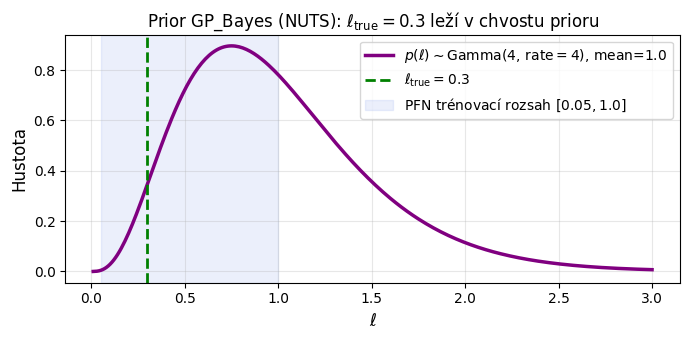

P(ℓ < 0.3 | prior) = 0.034  (3.4% kumulativní hmoty pod pravou hodnotou)
✓ Prediktory připraveny (GP_Bayes používá NUTS)


In [5]:
# =============================================
# PREDIKTORY — každá metoda
# =============================================

# ── NumPyro model: RBF GP s misspecifikovaným priorem ──────────────────────
# Prior p(ℓ) ~ Gamma(concentration=4, rate=4) → střed u ℓ=1.0
# Pravá hodnota ℓ=0.3 leží v chvostu (~7 % kumulativní hmoty)
def _nuts_gp_model(tx_jax, ty_jax, noise):
    ls = numpyro.sample('ls', dist.Gamma(concentration=4.0, rate=4.0))
    K  = jnp.exp(-0.5 * jnp.square(tx_jax[:, None] - tx_jax[None, :]) / ls**2)
    K  = K + (noise + 1e-6) * jnp.eye(len(tx_jax))
    numpyro.sample('y', dist.MultivariateNormal(jnp.zeros(len(tx_jax)), K), obs=ty_jax)


def predict_gp_oracle(tx, ty, te, ls_true, noise):
    """GP oracle: Matérn 2.5, správné HP."""
    return gp_posterior(tx, ty, te, matern25_kernel, ls_true, noise)


def predict_gp_fixed(tx, ty, te, ls_wrong, noise):
    """GP_fixed: RBF, fixní chybné ℓ."""
    return gp_posterior(tx, ty, te, rbf_kernel, ls_wrong, noise)


def predict_gp_ml(tx, ty, te, noise, ls_bounds=(0.01, 6.0)):
    """GP_ML: RBF, ℓ optimalizovaný přes log marginální věrohodnost."""
    def neg_lml(log_ls):
        return -rbf_log_marginal_lik(tx, ty, math.exp(log_ls), noise)
    res   = minimize_scalar(neg_lml,
                            bounds=(math.log(ls_bounds[0]), math.log(ls_bounds[1])),
                            method='bounded')
    ls_ml = math.exp(res.x)
    mu, var = gp_posterior(tx, ty, te, rbf_kernel, ls_ml, noise)
    return mu, var, ls_ml


def predict_gp_bayes(tx, ty, te, noise,
                     num_warmup=100, num_samples=200, rng_key=None):
    """
    Bayesovský GP s NUTS: vzorkuje p(ℓ | X, y) a průměruje predikce.
    Kernel: RBF (misspecifikovaný — data jsou z Matérn 2.5).
    Prior: p(ℓ) ~ Gamma(4, rate=4), střed u ℓ=1.0.
    """
    if rng_key is None:
        rng_key = jax.random.PRNGKey(0)
    tx_jax = jnp.array(tx)
    ty_jax = jnp.array(ty)

    mcmc = MCMC(
        NUTS(_nuts_gp_model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        progress_bar=False,
    )
    mcmc.run(rng_key, tx_jax, ty_jax, noise)
    ls_samples = np.array(mcmc.get_samples()['ls'])  # [num_samples]

    means, variances = [], []
    for ls_val in ls_samples:
        mu, var = gp_posterior(tx, ty, te, rbf_kernel, float(ls_val), noise)
        means.append(mu)
        variances.append(var)

    means     = np.array(means)      # [num_samples, n_test]
    variances = np.array(variances)
    mean_pred = means.mean(axis=0)
    # Zákon celkové variance: E[Var[y|ℓ]] + Var[E[y|ℓ]]
    var_pred  = (variances + (means - mean_pred) ** 2).mean(axis=0)
    return mean_pred, np.maximum(var_pred, 1e-10)


def predict_pfn(model, train_x_t, train_y_t, test_x_t, device):
    """Standardní PFN inference; vrací (mean_np, logits_tensor)."""
    with torch.no_grad():
        logits = model(
            train_x_t[None].to(device),
            train_y_t[None].to(device),
            test_x_t[None].to(device),
        )
    mean = model.criterion.mean(logits)[0].detach().cpu().numpy()
    return mean, logits


def pfn_nll(model, logits, y_test_t):
    """PFN NLL: -E[log p(y_test | logits)]. logits: [1, n_test, 1000]."""
    with torch.no_grad():
        log_probs = model.criterion(logits[0], y_test_t.to(logits[0].device))
    return float(-log_probs.mean().cpu().item())


# Vizualizace prioru GP_Bayes
fig, ax = plt.subplots(figsize=(7, 3.5))
ls_plot = np.linspace(0.01, 3.0, 300)
ax.plot(ls_plot, gamma_dist.pdf(ls_plot, a=4.0, scale=0.25),
        color='purple', lw=2.5, label='$p(\\ell) \\sim \\mathrm{Gamma}(4,\\, \\mathrm{rate}=4)$, mean=1.0')
ax.axvline(0.3, color='green', ls='--', lw=2, label='$\\ell_{\\mathrm{true}} = 0.3$')
ax.axvspan(0.05, 1.0, alpha=0.1, color='royalblue', label='PFN trénovací rozsah $[0.05, 1.0]$')
ax.set_xlabel('$\\ell$', fontsize=12)
ax.set_ylabel('Hustota', fontsize=12)
ax.set_title('Prior GP_Bayes (NUTS): $\\ell_{\\mathrm{true}}=0.3$ leží v chvostu prioru', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

p_at_03 = gamma_dist.cdf(0.3, a=4.0, scale=0.25)
print(f'P(ℓ < 0.3 | prior) = {p_at_03:.3f}  ({p_at_03*100:.1f}% kumulativní hmoty pod pravou hodnotou)')
print('✓ Prediktory připraveny (GP_Bayes používá NUTS)')

In [6]:
# =============================================
# GENEROVÁNÍ DAT + HLAVNÍ EXPERIMENT
# =============================================

def generate_matern25_data(n_context, n_test, ls_true, noise, osc=1.0, rng=None):
    """Generuje data z Matérn 2.5 GP; vrací pytorch tensory."""
    if rng is None:
        rng = np.random.default_rng()
    n_total = n_context + n_test
    x = np.sort(rng.uniform(0, 1, n_total))
    K = matern25_kernel(x, x, ls_true, osc) + noise * np.eye(n_total)
    try:
        L = np.linalg.cholesky(K)
        y = L @ rng.standard_normal(n_total)
    except np.linalg.LinAlgError:
        y = rng.multivariate_normal(np.zeros(n_total), K)

    train_x = torch.tensor(x[:n_context, None], dtype=torch.float32)
    train_y = torch.tensor(y[:n_context],        dtype=torch.float32)
    test_x  = torch.tensor(x[n_context:, None],  dtype=torch.float32)
    test_y  = torch.tensor(y[n_context:],         dtype=torch.float32)
    return train_x, train_y, test_x, test_y


def run_experiment(model, n_context, n_test, ls_true, noise, n_inst,
                   ls_wrong=0.7, seed=42,
                   nuts_warmup=100, nuts_samples=200):
    """
    Porovnává PFN vs GP varianty na datech z Matérn 2.5.
    GP_Bayes používá NUTS (NumPyro) pro vzorkování p(ℓ | X, y).

    NLL pro GP metody používá prediktivní varianci Var[y*] = Var[f*|X,y] + σ²,
    protože testovací hodnoty jsou y* = f* + ε, ε ~ N(0, σ²).
    """
    rng = np.random.default_rng(seed)
    acc = {m: {'mse': [], 'nll': []} for m in
           ['PFN', 'GP_fixed', 'GP_ML', 'GP_Bayes', 'GP_oracle']}

    for i in range(n_inst):
        train_x, train_y, test_x, test_y = generate_matern25_data(
            n_context, n_test, ls_true, noise, rng=rng
        )
        tx = train_x.numpy().reshape(-1)
        ty = train_y.numpy().reshape(-1)
        te = test_x.numpy().reshape(-1)
        ty_true = test_y.numpy().reshape(-1)

        # Oracle — musí uspět, jinak přeskočíme instanci
        try:
            mu_or, var_or = predict_gp_oracle(tx, ty, te, ls_true, noise)
            acc['GP_oracle']['mse'].append(float(np.mean((mu_or - ty_true)**2)))
            acc['GP_oracle']['nll'].append(gp_nll(mu_or, var_or + noise, ty_true))
        except Exception:
            continue

        # PFN
        try:
            mu_pfn, logits = predict_pfn(model, train_x, train_y, test_x, device)
            acc['PFN']['mse'].append(float(np.mean((mu_pfn - ty_true)**2)))
            acc['PFN']['nll'].append(pfn_nll(model, logits, test_y))
        except Exception:
            pass

        # GP_fixed
        try:
            mu_fix, var_fix = predict_gp_fixed(tx, ty, te, ls_wrong, noise)
            acc['GP_fixed']['mse'].append(float(np.mean((mu_fix - ty_true)**2)))
            acc['GP_fixed']['nll'].append(gp_nll(mu_fix, var_fix + noise, ty_true))
        except Exception:
            pass

        # GP_ML
        try:
            mu_ml, var_ml, _ = predict_gp_ml(tx, ty, te, noise)
            acc['GP_ML']['mse'].append(float(np.mean((mu_ml - ty_true)**2)))
            acc['GP_ML']['nll'].append(gp_nll(mu_ml, var_ml + noise, ty_true))
        except Exception:
            pass

        # GP_Bayes (NUTS) — každá instance dostane jiný klíč pro nezávislé řetězce
        try:
            rng_key = jax.random.PRNGKey(seed * 10000 + i)
            mu_bayes, var_bayes = predict_gp_bayes(
                tx, ty, te, noise,
                num_warmup=nuts_warmup, num_samples=nuts_samples,
                rng_key=rng_key,
            )
            acc['GP_Bayes']['mse'].append(float(np.mean((mu_bayes - ty_true)**2)))
            acc['GP_Bayes']['nll'].append(gp_nll(mu_bayes, var_bayes + noise, ty_true))
        except Exception:
            pass

    summary = {}
    for name, vals in acc.items():
        summary[name] = {}
        for metric in ('mse', 'nll'):
            arr = np.array(vals[metric])
            arr = arr[np.isfinite(arr)]
            if len(arr) > 0:
                summary[name][metric] = (float(arr.mean()), float(arr.std() / math.sqrt(len(arr))))
            else:
                summary[name][metric] = (np.nan, np.nan)
    return summary


print('✓ Experimentální funkce připraveny')
print('  GP NLL používá prediktivní varianci: Var[f*|X,y] + σ²')
print('  GP_Bayes používá NUTS — první volání bude pomalejší (JIT kompilace JAX)')


✓ Experimentální funkce připraveny
  GP NLL používá prediktivní varianci: Var[f*|X,y] + σ²
  GP_Bayes používá NUTS — první volání bude pomalejší (JIT kompilace JAX)


## Q1 — Jak chyba závisí na počtu trénovacích bodů $n$?

Fixní $\ell_{\text{true}} = 0.3$, šum $\sigma^2 = 0.1$.

S rostoucím $n$ mají všechny metody k dispozici více informací — data by měla postupně přebít vliv špatného prioru.
Otázka je: **jak rychle** a **jak moc** to platí pro každou metodu?

In [7]:
# =============================================
# -- SPUŠTĚNÍ Q1 --
# =============================================

LS_TRUE   = 0.3
NOISE     = 0.1
LS_WRONG  = 0.7
N_TEST    = 10
N_INST_Q1 = 150
N_VALUES  = [5, 10, 20, 40, 64, 100, 128]

print(f'Q1: ℓ_true={LS_TRUE}, noise={NOISE}, n_test={N_TEST}, inst={N_INST_Q1}')
print(f'    GP_fixed ℓ = {LS_WRONG}  |  GP_Bayes prior: Gamma(4, rate=4)\n')

q1_results = {}
for n in N_VALUES:
    print(f'  n={n:3d}...', end=' ', flush=True)
    q1_results[n] = run_experiment(
        model_pfn, n, N_TEST, LS_TRUE, NOISE, N_INST_Q1, ls_wrong=LS_WRONG
    )
    print('✓')

METHODS = ['PFN', 'GP_fixed', 'GP_ML', 'GP_Bayes', 'GP_oracle']

print(f'\n{"":─<70}')
print('Q1 — MSE (predikce vs. pravé testovací hodnoty)')
print(f'{"n":>5}  ' + '  '.join(f'{m:>10}' for m in METHODS))
print(f'{"":─<70}')
for n in N_VALUES:
    row = f'{n:>5}  '
    for m in METHODS:
        row += f'{q1_results[n][m]["mse"][0]:>10.5f}  '
    print(row)

print(f'\n{"":─<70}')
print('Q1 — ΔNLL = NLL_metoda − NLL_oracle  (záporné = lepší než oracle, 0 = stejně dobrý)')
print(f'{"n":>5}  ' + '  '.join(f'{m:>10}' for m in METHODS))
print(f'{"":─<70}')
for n in N_VALUES:
    nll_ref = q1_results[n]['GP_oracle']['nll'][0]
    row = f'{n:>5}  '
    for m in METHODS:
        row += f'{q1_results[n][m]["nll"][0] - nll_ref:>+10.4f}  '
    print(row)


Q1: ℓ_true=0.3, noise=0.1, n_test=10, inst=150
    GP_fixed ℓ = 0.7  |  GP_Bayes prior: Gamma(4, 0.25)

  n=  5... ✓
  n= 10... ✓
  n= 20... ✓
  n= 40... ✓
  n= 64... ✓
  n=100... ✓
  n=128... ✓

──────────────────────────────────────────────────────────────────────
Q1 — MSE (predikce vs. pravé testovací hodnoty)
    n         PFN    GP_fixed       GP_ML    GP_Bayes   GP_oracle
──────────────────────────────────────────────────────────────────────
    5     0.96374     1.18172     0.95305     0.98592     0.79025  
   10     0.86215     1.00189     0.72144     0.73947     0.66794  
   20     0.66448     0.78485     0.55354     0.54532     0.47545  
   40     0.58630     0.62423     0.41614     0.39967     0.35816  
   64     0.33392     0.49483     0.26753     0.26891     0.24434  
  100     0.24625     0.38220     0.18626     0.18506     0.17135  
  128     0.23440     0.41661     0.17169     0.18200     0.16918  

──────────────────────────────────────────────────────────────────────


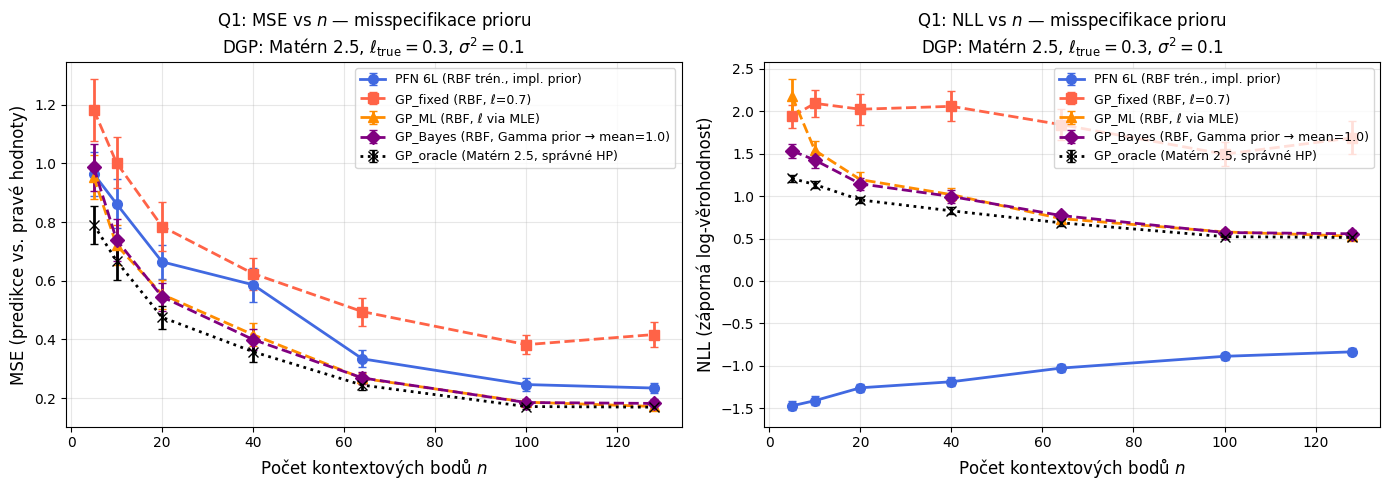

In [8]:
# =============================================
# VIZUALIZACE Q1
# =============================================

METHOD_COLORS = {
    'PFN':       'royalblue',
    'GP_fixed':  'tomato',
    'GP_ML':     'darkorange',
    'GP_Bayes':  'purple',
    'GP_oracle': 'black',
}
METHOD_FMT = {
    'PFN':       '-o',
    'GP_fixed':  '--s',
    'GP_ML':     '--^',
    'GP_Bayes':  '--D',
    'GP_oracle': ':x',
}
METHOD_LABELS = {
    'PFN':       'PFN 6L (impl. prior)',
    'GP_fixed':  f'GP_fixed (RBF, ℓ={LS_WRONG})',
    'GP_ML':     'GP_ML (RBF, Type-II ML)',
    'GP_Bayes':  'GP_Bayes (NUTS, Gamma prior)',
    'GP_oracle': 'GP_oracle (Matérn 2.5, správné HP)',
}

ns = np.array(N_VALUES, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Levý panel: MSE
ax = axes[0]
for name in METHODS:
    vals = [q1_results[n][name]['mse'][0] for n in N_VALUES]
    stes = [q1_results[n][name]['mse'][1] for n in N_VALUES]
    ax.errorbar(ns, vals, yerr=stes, fmt=METHOD_FMT[name],
                color=METHOD_COLORS[name], lw=2, ms=7, capsize=3,
                label=METHOD_LABELS[name])
ax.set_xlabel('Počet kontextových bodů $n$', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title(
    f'Q1: MSE vs $n$\nDGP: Matérn 2.5, $\\ell_{{true}}={LS_TRUE}$, $\\sigma^2={NOISE}$',
    fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Pravý panel: ΔNLL
ax = axes[1]
ax.axhline(0, color='black', lw=1.5, ls=':', label='Oracle (referenční 0)')
for name in METHODS:
    if name == 'GP_oracle':
        continue
    vals = [q1_results[n][name]['nll'][0] - q1_results[n]['GP_oracle']['nll'][0]
            for n in N_VALUES]
    stes = [q1_results[n][name]['nll'][1] for n in N_VALUES]
    ax.errorbar(ns, vals, yerr=stes, fmt=METHOD_FMT[name],
                color=METHOD_COLORS[name], lw=2, ms=7, capsize=3,
                label=METHOD_LABELS[name])
ax.set_xlabel('Počet kontextových bodů $n$', fontsize=12)
ax.set_ylabel('ΔNLL oproti oracle', fontsize=12)
ax.set_title(
    'Q1: ΔNLL vs $n$\n'
    'Záporné = lepší než oracle, kladné = horší', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Q2 — Jak chyba závisí na $\ell_{\text{true}}$ (síla misspecifikace)?

Fixní $n = 40$, šum $\sigma^2 = 0.1$. Meníme $\ell_{\text{true}}$ od 0.05 do 2.0.

Čím více se $\ell_{\text{true}}$ liší od toho, co každá metoda očekávala, tím horší by měla být její přesnost.
Ale liší se rychlost, s jakou degraduje:

- PFN byl trénován na $\ell \in [0.05, 1.0]$ — co se stane pro $\ell > 1.0$?
- GP_Bayes má prior soustředěný kolem $\ell = 1.0$ — pro $\ell$ blízko 1.0 by měl vycházet lépe než pro $\ell = 0.3$.
- GP_ML na prioru nezávisí — degraduje monotónně s tím, jak RBF přestává aproximovat Matérn 2.5?

In [9]:
# =============================================
# -- SPUŠTĚNÍ Q2 --
# =============================================

N_FIXED   = 40
N_TEST_Q2 = 10
N_INST_Q2 = 150
LS_VALUES = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

print(f'Q2: n={N_FIXED}, noise={NOISE}, n_test={N_TEST_Q2}, inst={N_INST_Q2}')
print(f'    LS_VALUES = {LS_VALUES}\n')

q2_results = {}
for ls in LS_VALUES:
    print(f'  ℓ_true={ls:.2f}...', end=' ', flush=True)
    q2_results[ls] = run_experiment(
        model_pfn, N_FIXED, N_TEST_Q2, ls, NOISE, N_INST_Q2, ls_wrong=LS_WRONG
    )
    print('✓')

METHODS_Q2 = ['PFN', 'GP_fixed', 'GP_ML', 'GP_Bayes', 'GP_oracle']

print(f'\n{"":─<72}')
print('Q2 — MSE')
print(f'{"l_true":>8}  ' + '  '.join(f'{m:>10}' for m in METHODS_Q2))
print(f'{"":─<72}')
for ls in LS_VALUES:
    row = f'{ls:>8.3f}  '
    for m in METHODS_Q2:
        row += f'{q2_results[ls][m]["mse"][0]:>10.5f}  '
    print(row)

print(f'\n{"":─<72}')
print('Q2 — ΔNLL = NLL_metoda − NLL_oracle  (záporné = lepší než oracle, 0 = stejně dobrý)')
print(f'{"l_true":>8}  ' + '  '.join(f'{m:>10}' for m in METHODS_Q2))
print(f'{"":─<72}')
for ls in LS_VALUES:
    nll_ref = q2_results[ls]['GP_oracle']['nll'][0]
    row = f'{ls:>8.3f}  '
    for m in METHODS_Q2:
        row += f'{q2_results[ls][m]["nll"][0] - nll_ref:>+10.4f}  '
    print(row)


Q2: n=40, noise=0.1, n_test=10, inst=150
    LS_VALUES = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

  ℓ_true=0.05... ✓
  ℓ_true=0.10... ✓
  ℓ_true=0.20... ✓
  ℓ_true=0.30... ✓
  ℓ_true=0.50... ✓
  ℓ_true=0.70... ✓
  ℓ_true=1.00... ✓
  ℓ_true=1.50... ✓
  ℓ_true=2.00... ✓

────────────────────────────────────────────────────────────────────────
Q2 — MSE
  l_true         PFN    GP_fixed       GP_ML    GP_Bayes   GP_oracle
────────────────────────────────────────────────────────────────────────
   0.050     1.05267     2.00588     0.99193     0.98868     0.98116  
   0.100     0.89944     1.87695     0.81220     0.81922     0.78140  
   0.200     0.64402     1.13399     0.57635     0.56389     0.50696  
   0.300     0.58630     0.62423     0.41614     0.39967     0.35816  
   0.500     0.46354     0.27506     0.25383     0.23612     0.23189  
   0.700     0.40345     0.18896     0.19154     0.18329     0.18401  
   1.000     0.36766     0.15438     0.15891     0.15302     0.15353  
  

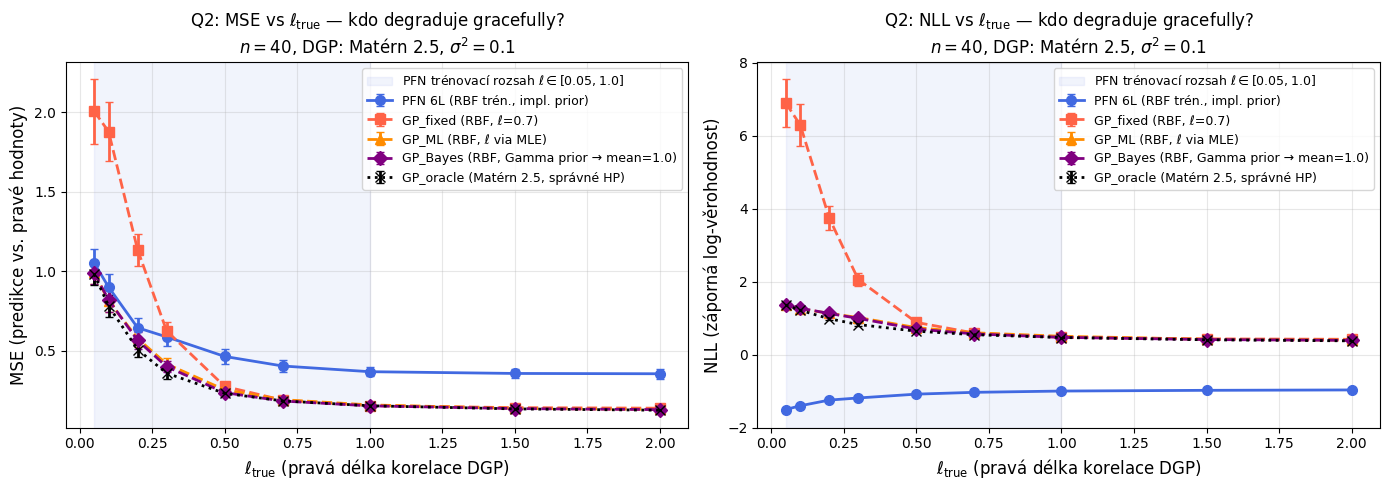

In [10]:
# =============================================
# VIZUALIZACE Q2
# =============================================

ls_arr = np.array(LS_VALUES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Levý panel: MSE
ax = axes[0]
for name in METHODS_Q2:
    vals = [q2_results[ls][name]['mse'][0] for ls in LS_VALUES]
    stes = [q2_results[ls][name]['mse'][1] for ls in LS_VALUES]
    ax.errorbar(ls_arr, vals, yerr=stes, fmt=METHOD_FMT[name],
                color=METHOD_COLORS[name], lw=2, ms=7, capsize=3,
                label=METHOD_LABELS[name])
ax.axvspan(0.05, 1.0, alpha=0.07, color='royalblue',
           label='PFN trénovací rozsah')
ax.set_xlabel('$\\ell_{true}$', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title(
    f'Q2: MSE vs $\\ell_{{true}}$\n$n={N_FIXED}$, $\\sigma^2={NOISE}$',
    fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Pravý panel: ΔNLL
ax = axes[1]
ax.axhline(0, color='black', lw=1.5, ls=':', label='Oracle (referenční 0)')
for name in METHODS_Q2:
    if name == 'GP_oracle':
        continue
    vals = [q2_results[ls][name]['nll'][0] - q2_results[ls]['GP_oracle']['nll'][0]
            for ls in LS_VALUES]
    stes = [q2_results[ls][name]['nll'][1] for ls in LS_VALUES]
    ax.errorbar(ls_arr, vals, yerr=stes, fmt=METHOD_FMT[name],
                color=METHOD_COLORS[name], lw=2, ms=7, capsize=3,
                label=METHOD_LABELS[name])
ax.axvspan(0.05, 1.0, alpha=0.07, color='royalblue',
           label='PFN trénovací rozsah')
ax.set_xlabel('$\\ell_{true}$', fontsize=12)
ax.set_ylabel('ΔNLL oproti oracle', fontsize=12)
ax.set_title(
    'Q2: ΔNLL vs $\\ell_{true}$\n'
    'Záporné = lepší než oracle, kladné = horší', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Interpretace výsledků

### Shrnutí misspecifikace každé metody

| Metoda | Co je špatně na kernelu | Co je špatně na odhadu $\ell$ |
|---|---|---|
| PFN | Implicitní RBF (trénovací distribuce) | Implicitní $U(0.05, 1.0)$, nelze opravit za běhu |
| GP_fixed | RBF místo Matérn 2.5 | Fixní $\ell = 0.7$, nic se nepřizpůsobuje |
| GP_ML | RBF místo Matérn 2.5 | Bodový MLE odhad — přizpůsobí se datům, ale ignoruje nejistotu o $\ell$ |
| GP_Bayes | RBF místo Matérn 2.5 | NUTS s Gamma(4, rate=4) priorem: střed u $\ell=1.0$, $\ell=0.3$ v chvostu |
| GP_oracle | Správný Matérn 2.5 | Správné $\ell = \ell_{\text{true}}$ (referenční podvod) |

### Co hledat v grafech

**Q1 — chyba vs. $n$:**

- **GP_Bayes vs. GP_ML**: Pro malá $n$ je GP_Bayes horší, protože špatný prior tlačí $\ell$ od pravé hodnoty. S rostoucím $n$ věrohodnost přepíše prior a GP_Bayes konverguje k GP_ML.
- **PFN**: prior zakódovaný v váhách nelze přepsat daty → může se projevit jako plateau v MSE.
- **GP_fixed**: nepřizpůsobuje se vůbec → pro velká $n$ zůstává pozadu.
- **NLL pro malá $n$**: Všechny metody jsou hodně nejisté → NLL se liší méně. Přílišná sebejistota (úzký interval) dá horší NLL než správná nejistota.

**Q2 — chyba vs. $\ell_{\text{true}}$:**

- **GP_Bayes** by měl být nejlepší ze špatných metod pro $\ell \approx 1.0$ (střed prioru).
- **PFN** by měl degradovat pro $\ell > 1.0$, kde nikdy netrénoval.
- **GP_ML** nezávisí na prioru — degraduje kvůli špatnému kernelu, ne kvůli $\ell$.

**Klíčová strukturální otázka:**

GP_Bayes nese misspecifikaci v *explicitním* prioru — data ho postupně přepíší (bayesovská konzistence).
PFN nese misspecifikaci v *implicitním* prioru zakódovaném v síti — ta se za běhu nemění.
Pro velká $n$ oba narazí na strop daný špatným kernelem (RBF vs. Matérn 2.5).
